# Charting Boulder — Response to the Restaurant Industry Rebuttal
**Brian C. Keegan, Ph.D. · June 2026 · MIT License**

A reproducible response to *"Restaurant groups: The data professor got Boulder
restaurant wages wrong"* (Boulder Reporting Lab, June 18, 2026).

This notebook answers three things with auditable public data:

1. **The hours-consistency problem.** The rebuttal divides full-time, year-round
   Census earnings by part-time hours to inflate the implied hourly wage. This
   section shows why that is internally incoherent, and what honest, consistent
   annualization produces.
2. **The employment-decline claim.** The rebuttal asserts a 3.4% decline in
   full-service restaurant employment. QCEW lets us audit it directly — and
   contextualize it against Colorado and national baselines.
3. **The occupation-specificity critique (their one fair point).** The ACS
   "food service" category is broad. OEWS gives occupation-specific wages —
   waiters, bartenders — *including tips*. This section reads those from the
   local OEWS pipeline output.

**Live data sources (no key required):** BLS QCEW Open Data API.  
**Keyed / local sources:** Census ACS (set `CENSUS_API_KEY`); OEWS occupation
wages (from `oews_boulder_combined.csv`, produced by `oews_boulder.py`).


## 0. Setup & Configuration

In [21]:
import io, json, urllib.request, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "font.family": "sans-serif",
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
})

# Palette
C_CLAIM  = "#f46d43"   # the $40 industry claim
C_ACTUAL = "#1a9641"   # actual census/OEWS earnings
C_BOULDER= "#d73027"   # Boulder
C_CO     = "#4575b4"   # Colorado
C_US     = "#7f7f7f"   # United States
C_RENT   = "#2166ac"

# ── Config ────────────────────────────────────────────────────────────────────
CENSUS_API_KEY = ""   # optional: paste your key to enable live ACS pulls
OEWS_CSV       = Path("oews_boulder_combined.csv")   # output of oews_boulder.py

def fetch(url, headers=None):
    req = urllib.request.Request(url, headers=headers or {"User-Agent": "Mozilla/5.0"})
    return urllib.request.urlopen(req, timeout=30).read()

print("Setup complete.")

Setup complete.


## 1. The Hours-Consistency Problem

The rebuttal's core accusation: dividing annual Census earnings by 2,080 hours
"skews" the result, and a "more honest" 25–30 hour week yields $29–$35/hr.

The flaw: **ACS Table B24022 reports earnings for full-time, year-round workers
only** — people who worked 35+ hours/week and 50+ weeks/year. Dividing that
numerator by a *part-time* denominator describes a worker who does not exist:
one earning a full-timer's annual total on a part-timer's schedule.

The fair test is **consistency**: apply the *same* hours assumption to both
the $40/hr claim and the Census earnings. Councilmember Benjamin annualized
his $40/hr at 40 hrs × 50 wks = $80,000. We apply that same basis to the
Census median.


In [2]:
# Published ACS B24022 figures (Boulder County, full-time year-round, 2024)
ACS_MALE_2024   = 46305   # $/yr median, male food service
ACS_FEMALE_2024 = 44970   # $/yr median, female food service
BENJAMIN_HOURLY = 40.00   # industry survey claim, $/hr

# Hour bases to test
bases = {
    "Benjamin's basis (40h x 50wk)": 40*50,   # 2000 — what Benjamin used for $80k
    "BLS standard (40h x 52wk)":     40*52,   # 2080 — the conventional FTE
    "Rebuttal's claim (30h x 52wk)": 30*52,   # 1560
    "Rebuttal's claim (25h x 52wk)": 25*52,   # 1300
}

print("What each number annualizes/hourly-izes to, by hours basis:\n")
print(f"{'Hours basis':<32} {'hrs/yr':>7} {'$40/hr ->':>12} {'ACS male ->':>12}")
print("-" * 68)
rows = {}
for label, hrs in bases.items():
    benj_annual = BENJAMIN_HOURLY * hrs
    acs_hourly  = ACS_MALE_2024 / hrs
    rows[label] = (hrs, benj_annual, acs_hourly)
    print(f"{label:<32} {hrs:>7,} {'$'+format(benj_annual,',.0f'):>12} {'$'+format(acs_hourly,',.2f')+'/hr':>12}")

print()
print("THE INCONSISTENCY THE REBUTTAL RELIES ON:")
print(f"  - To inflate the Census wage, it uses part-time hours (1,300-1,560/yr).")
print(f"  - But the $40/hr -> $80,000 claim assumed full-time hours (2,000/yr).")
print(f"  - Apply part-time hours to BOTH and Benjamin's $80k claim collapses:")
benj_pt = BENJAMIN_HOURLY * (27.5*52)
print(f"      $40/hr x 27.5h x 52wk = ${benj_pt:,.0f}, not $80,000.")
print(f"  - And a worker at 27.5 h/wk earns LESS annually, widening the rent gap.")
print()
print("THE DIRECTION-OF-BIAS ERROR:")
print(f"  B24022 excludes part-timers. Including them lowers the typical annual")
print(f"  earnings -> the real picture is WORSE for workers, not better.")

What each number annualizes/hourly-izes to, by hours basis:

Hours basis                       hrs/yr    $40/hr ->  ACS male ->
--------------------------------------------------------------------
Benjamin's basis (40h x 50wk)      2,000      $80,000    $23.15/hr
BLS standard (40h x 52wk)          2,080      $83,200    $22.26/hr
Rebuttal's claim (30h x 52wk)      1,560      $62,400    $29.68/hr
Rebuttal's claim (25h x 52wk)      1,300      $52,000    $35.62/hr

THE INCONSISTENCY THE REBUTTAL RELIES ON:
  - To inflate the Census wage, it uses part-time hours (1,300-1,560/yr).
  - But the $40/hr -> $80,000 claim assumed full-time hours (2,000/yr).
  - Apply part-time hours to BOTH and Benjamin's $80k claim collapses:
      $40/hr x 27.5h x 52wk = $57,200, not $80,000.
  - And a worker at 27.5 h/wk earns LESS annually, widening the rent gap.

THE DIRECTION-OF-BIAS ERROR:
  B24022 excludes part-timers. Including them lowers the typical annual
  earnings -> the real picture is WORSE for wor

### Figure 1 — The same numbers, honestly annualized

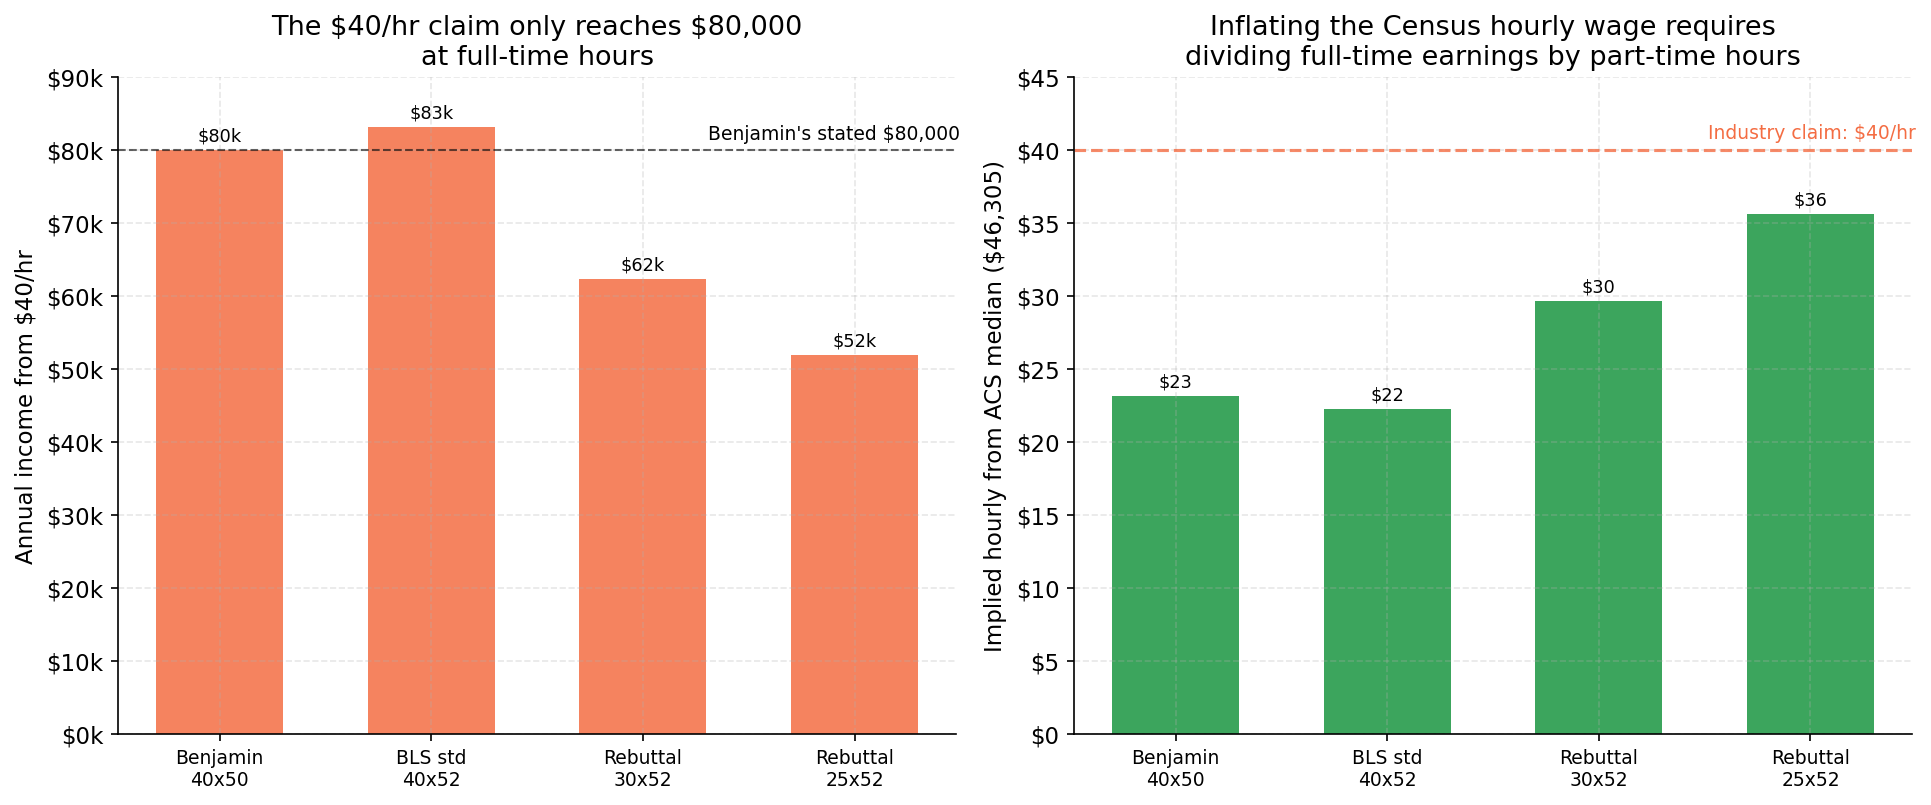

Saved: resp_fig1_hours_consistency.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

labels   = list(bases.keys())
hrs_list = [bases[l] for l in labels]
benj_ann = [BENJAMIN_HOURLY*h for h in hrs_list]
acs_hr   = [ACS_MALE_2024/h for h in hrs_list]
xpos     = np.arange(len(labels))
short    = ["Benjamin\n40x50", "BLS std\n40x52", "Rebuttal\n30x52", "Rebuttal\n25x52"]

# Left: what $40/hr annualizes to
b1 = ax1.bar(xpos, benj_ann, color=C_CLAIM, alpha=0.85, width=0.6)
ax1.axhline(80000, color="black", lw=1, ls="--", alpha=0.6)
ax1.text(len(labels)-0.5, 81500, "Benjamin's stated $80,000", ha="right", fontsize=9)
ax1.set_xticks(xpos); ax1.set_xticklabels(short, fontsize=9)
ax1.set_ylabel("Annual income from $40/hr")
ax1.set_title("The \$40/hr claim only reaches $80,000\nat full-time hours")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}k"))
ax1.set_ylim((0,90000))
for x, v in zip(xpos, benj_ann):
    ax1.text(x, v+1200, f"${v/1000:.0f}k", ha="center", fontsize=8.5)

# Right: what the ACS median hourly-izes to
b2 = ax2.bar(xpos, acs_hr, color=C_ACTUAL, alpha=0.85, width=0.6)
ax2.axhline(40, color=C_CLAIM, lw=1.5, ls="--", alpha=0.8)
ax2.text(len(labels)-0.5, 40.8, "Industry claim: $40/hr", ha="right", fontsize=9, color=C_CLAIM)
ax2.set_xticks(xpos); ax2.set_xticklabels(short, fontsize=9)
ax2.set_ylabel("Implied hourly from ACS median ($46,305)")
ax2.set_title("Inflating the Census hourly wage requires\ndividing full-time earnings by part-time hours")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}"))
ax2.set_ylim((0,45))
for x, v in zip(xpos, acs_hr):
    ax2.text(x, v+0.6, f"${v:.0f}", ha="center", fontsize=8.5)


plt.tight_layout()
plt.savefig("resp_fig1_hours_consistency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resp_fig1_hours_consistency.png")

## 2. Auditing the Employment-Decline Claim (QCEW)

The rebuttal: *"Boulder's full-service restaurant employment has already declined
3.4% from 2023 to 2025."* This is checkable. The Quarterly Census of Employment
and Wages (QCEW) covers NAICS 722511 (full-service restaurants) and runs through
more recent quarters than County Business Patterns.

We pull Boulder County and benchmark it against Colorado and the United States.
No API key required.


In [ ]:
def qcew_annual(fips, year):
    url = f"https://data.bls.gov/cew/data/api/{year}/a/area/{fips}.csv"
    df = pd.read_csv(io.BytesIO(fetch(url)), dtype=str)
    return df[df["own_code"] == "5"]   # private ownership

AREAS = {"08013": "Boulder County", "08000": "Colorado", "US000": "United States"}
NAICS = {"722511": "Full-service restaurants", "7225": "All restaurants/eating places"}

records = []
for fips, area in AREAS.items():
    for yr in range(2018, 2026):
        try:
            df = qcew_annual(fips, yr)
            for naics, nm in NAICS.items():
                r = df[df["industry_code"] == naics]
                if len(r):
                    records.append({
                        "area": area, "naics": naics, "naics_name": nm, "year": yr,
                        "estabs": float(r["annual_avg_estabs"].iloc[0]),
                        "employment": float(r["annual_avg_emplvl"].iloc[0]),
                        "total_wages": float(r["total_annual_wages"].iloc[0]),
                    })
        except Exception as e:
            print(f"  {area} {yr}: {e}")

qcew_df = pd.DataFrame(records)
qcew_df["avg_annual_wage"] = qcew_df["total_wages"] / qcew_df["employment"]

qcew_df.to_csv('qcew.csv',index=False,encoding='utf8')

In [12]:
# Headline: full-service employment change 2023 -> 2025
fs = qcew_df[qcew_df["naics"] == "722511"]
print("Full-service restaurant (NAICS 722511) employment, 2023 -> 2025:\n")
print(f"{'Area':<16} {'2023':>10} {'2025':>10} {'change':>9}")
print("-" * 48)
for area in AREAS.values():
    a = fs[(fs["area"]==area) & (fs["year"]==2023)]
    b = fs[(fs["area"]==area) & (fs["year"]==2025)]
    if len(a) and len(b):
        e23, e25 = a["employment"].iloc[0], b["employment"].iloc[0]
        print(f"{area:<16} {e23:>10,.0f} {e25:>10,.0f} {(e25/e23-1)*100:>+8.1f}%")

Full-service restaurant (NAICS 722511) employment, 2023 -> 2025:

Area                   2023       2025    change
------------------------------------------------
Boulder County        7,807      7,270     -6.9%
Colorado            110,028    106,321     -3.4%
United States     5,331,268  5,336,036     +0.1%


### Figure 2 — Restaurant employment, indexed (2019 = 100)

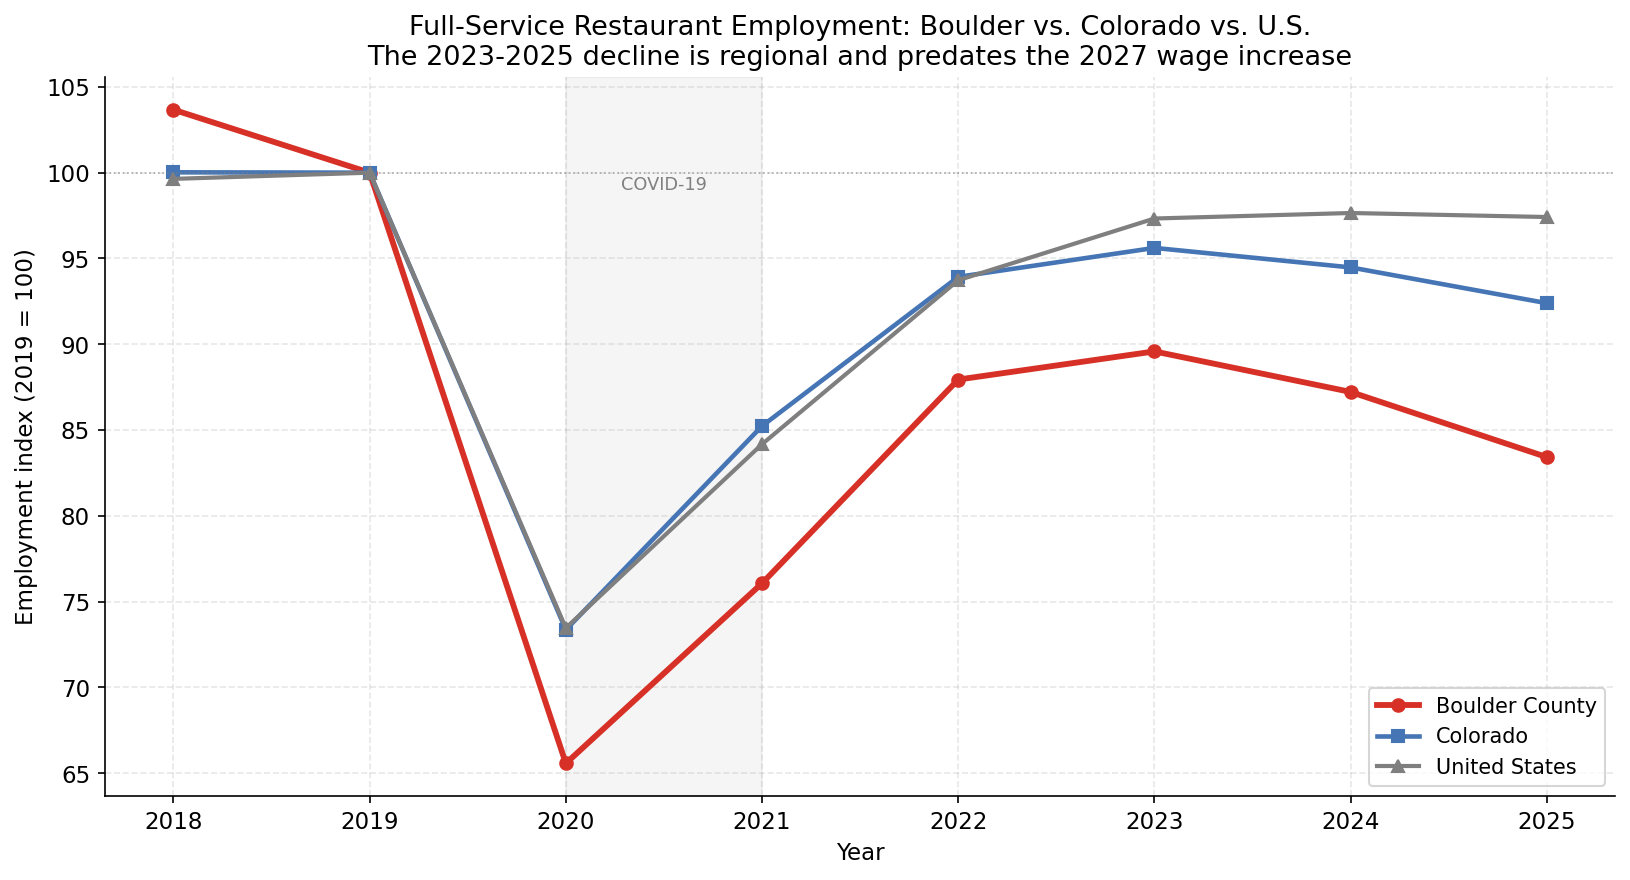

Saved: resp_fig2_employment_audit.png


In [18]:
fig, ax = plt.subplots(figsize=(11, 6))

fs = qcew_df[qcew_df["naics"] == "722511"].copy()
styles = {"Boulder County": (C_BOULDER, 2.8, "o"),
          "Colorado":       (C_CO, 2.2, "s"),
          "United States":  (C_US, 2.0, "^")}

for area, (color, lw, mk) in styles.items():
    s = fs[fs["area"] == area].sort_values("year")
    if s.empty:
        continue
    base = s[s["year"] == 2019]["employment"].iloc[0]
    idx = s["employment"] / base * 100
    ax.plot(s["year"], idx, color=color, lw=lw, marker=mk, ms=6, label=area)

ax.axhline(100, color="gray", lw=0.8, ls=":", alpha=0.6)
ax.axvspan(2020, 2021, color="gray", alpha=0.08)
ax.text(2020.5, 99, "COVID-19", ha="center", fontsize=8.5, color="gray")
# Mark 2027 wage increase (future)
# ax.axvline(2025, color="black", lw=0.8, ls="--", alpha=0.4)
# ax.annotate("2027 wage increase\nnot yet in effect",
#             xy=(2025, 88), xytext=(2022.5, 78), fontsize=8.5, color="black",
#             arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.set_xlabel("Year")
ax.set_ylabel("Employment index (2019 = 100)")
ax.set_title("Full-Service Restaurant Employment: Boulder vs. Colorado vs. U.S.\n"
             "The 2023-2025 decline is regional and predates the 2027 wage increase")
ax.legend(loc="lower right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}"))

plt.tight_layout()
plt.savefig("resp_fig2_employment_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resp_fig2_employment_audit.png")

## 3. Occupation-Specific Wages, Tips Included (OEWS)

The rebuttal's one fair point: the ACS "food service" category includes cooks,
dishwashers, and fast-food workers, not just tipped servers and bartenders.

OEWS answers this directly. It reports wages by detailed occupation —
35-3031 (Waiters/Waitresses), 35-3011 (Bartenders) — and its wage estimates
**include tips**, because they are built from total employer-reported earnings.

This section reads the OEWS panel produced by `oews_boulder.py`
(`oews_boulder_combined.csv`). If that file is not present, it falls back to
`STUB_MODE` with documented Colorado statewide reference values so the notebook
runs end to end. **Replace stub values by running your OEWS pipeline.**


In [22]:
TIPPED_SOC = {
    "35-3031": "Waiters & Waitresses",
    "35-3011": "Bartenders",
    "35-2014": "Cooks, Restaurant (back-of-house)",
    "35-9021": "Dishwashers (back-of-house)",
}
PCT_COLS = ["h_pct10", "h_pct25", "h_median", "h_pct75", "h_pct90"]


print(f"Loading {OEWS_CSV} ...")
oews = pd.read_csv(OEWS_CSV, dtype=str)
# Most recent year, tipped + back-of-house occupations
oews["year"] = pd.to_numeric(oews["year"], errors="coerce")
latest_year = int(oews["year"].max())
print(f"Latest OEWS year in file: {latest_year}")
sub = oews[(oews["year"]==latest_year) & (oews["occ_code"].isin(TIPPED_SOC))].copy()
for c in PCT_COLS:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")
oews_latest = sub[["occ_code","occ_title"] + [c for c in PCT_COLS if c in sub.columns]]

print(oews_latest.to_string(index=False))
print()
print(f"$40/hr vs. the 90th percentile of each occupation:")
for _, r in oews_latest.iterrows():
    p90 = r.get("h_pct90", float('nan'))
    if pd.notna(p90):
        print(f"  {r['occ_title']:<34} p90=${p90:.2f}/hr  ->  $40 is {40/p90:.1f}x the 90th pct")

Loading oews_boulder_combined.csv ...
Latest OEWS year in file: 2025
occ_code              occ_title  h_pct10  h_pct25  h_median  h_pct75  h_pct90
 35-2014      Cooks, Restaurant    16.51    18.03     20.30    22.29    26.25
 35-3011             Bartenders    15.96    16.84     20.44    30.64    44.25
 35-3031 Waiters and Waitresses    16.25    17.00     23.97    34.56    38.91
 35-9021            Dishwashers    16.12    17.49     18.15    20.57    24.70

$40/hr vs. the 90th percentile of each occupation:
  Cooks, Restaurant                  p90=$26.25/hr  ->  $40 is 1.5x the 90th pct
  Bartenders                         p90=$44.25/hr  ->  $40 is 0.9x the 90th pct
  Waiters and Waitresses             p90=$38.91/hr  ->  $40 is 1.0x the 90th pct
  Dishwashers                        p90=$24.70/hr  ->  $40 is 1.6x the 90th pct


### Figure 3 — Wage distribution by occupation vs. the $40 claim

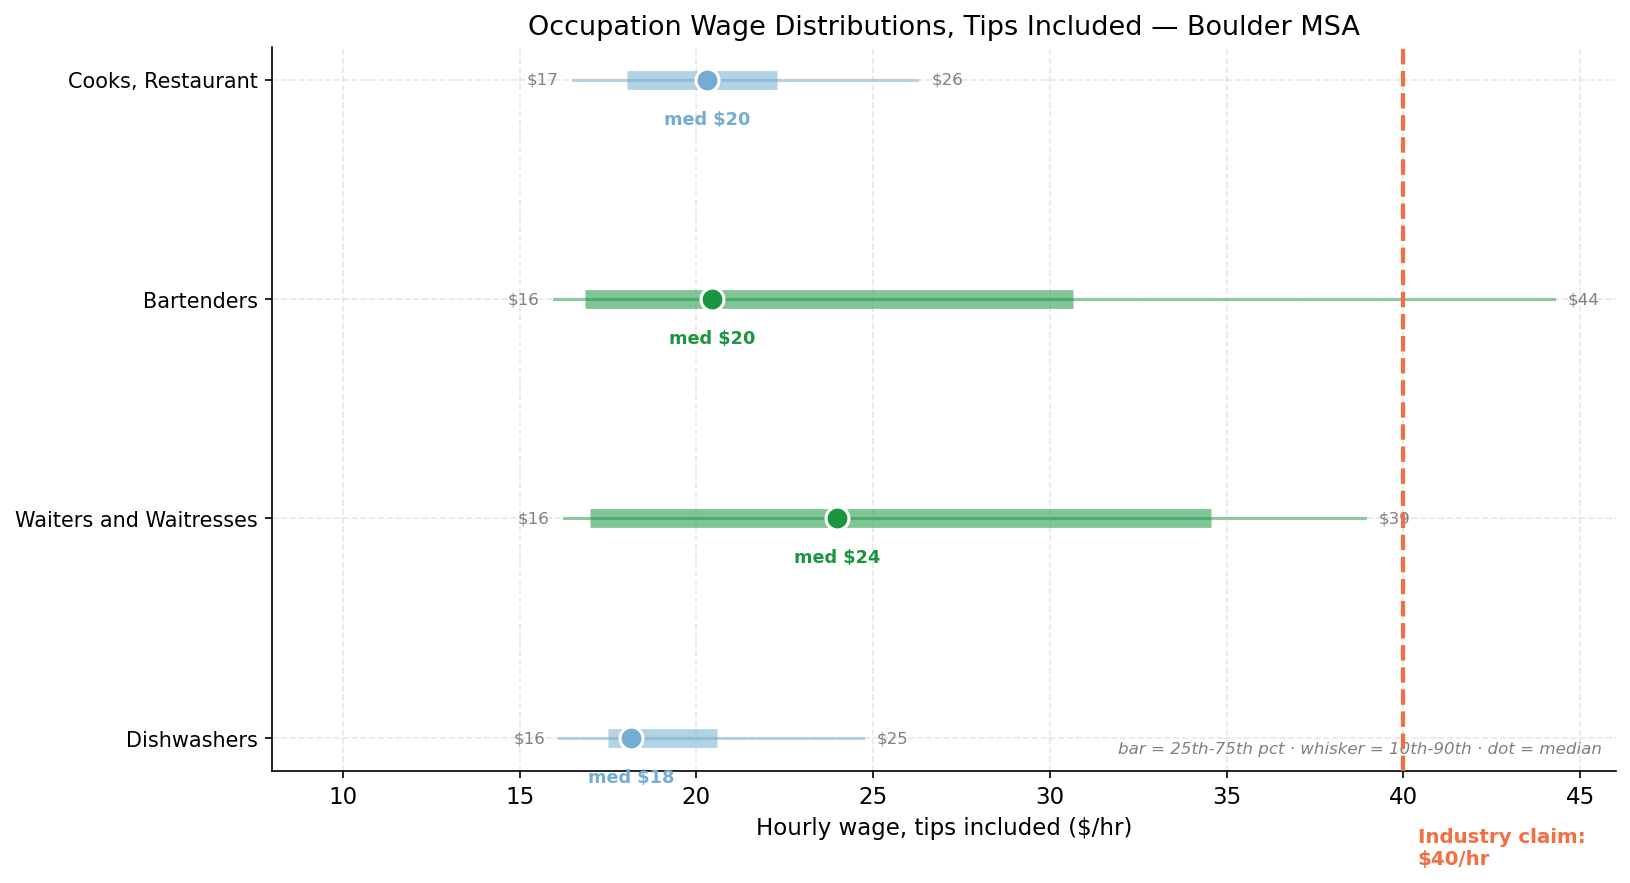

Saved: resp_fig3_oews_distribution.png


In [24]:
fig, ax = plt.subplots(figsize=(11, 6))

occs = oews_latest.to_dict("records")
ypos = np.arange(len(occs))
colors_occ = [C_ACTUAL if o["occ_code"] in ("35-3031","35-3011") else "#74add1" for o in occs]

for i, o in enumerate(occs):
    p10, p25, p50 = o.get("h_pct10"), o.get("h_pct25"), o.get("h_median")
    p75, p90 = o.get("h_pct75"), o.get("h_pct90")
    # 10-90 whisker
    ax.plot([p10, p90], [i, i], color=colors_occ[i], lw=1.5, alpha=0.5, zorder=1)
    # 25-75 box
    ax.plot([p25, p75], [i, i], color=colors_occ[i], lw=9, alpha=0.55, zorder=2,
            solid_capstyle="butt")
    # median marker
    ax.plot(p50, i, "o", color=colors_occ[i], ms=11, zorder=3,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.text(p10-0.4, i, f"${p10:.0f}", va="center", ha="right", fontsize=8, color="gray")
    ax.text(p90+0.4, i, f"${p90:.0f}", va="center", ha="left", fontsize=8, color="gray")
    ax.text(p50, i+0.22, f"med ${p50:.0f}", va="bottom", ha="center", fontsize=8.5,
            fontweight="bold", color=colors_occ[i])

# The $40 claim line
ax.axvline(40, color=C_CLAIM, lw=2, ls="--", zorder=4)
ax.text(40.4, len(occs)-0.5, "Industry claim:\n$40/hr", color=C_CLAIM, fontsize=9.5,
        va="center", fontweight="bold")

ax.set_yticks(ypos)
ax.set_yticklabels([o["occ_title"] for o in occs], fontsize=10)
ax.set_xlabel("Hourly wage, tips included ($/hr)")
ax.set_xlim(8, 46)
title_src = "Boulder MSA"
ax.set_title(f"Occupation Wage Distributions, Tips Included — {title_src}")
ax.invert_yaxis()

# Legend for box meaning
ax.text(0.99, 0.02, "bar = 25th-75th pct · whisker = 10th-90th · dot = median",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="gray", style="italic")

plt.tight_layout()
plt.savefig("resp_fig3_oews_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resp_fig3_oews_distribution.png")

## 4. Summary — Numbers for the Column

In [29]:
print("=" * 64)
print("RESPONSE TO RESTAURANT INDUSTRY REBUTTAL — KEY NUMBERS")
print("=" * 64)

print("\n[1] HOURS CONSISTENCY")
print(f"  ACS B24022 = FULL-TIME, YEAR-ROUND workers only (35+ hrs, 50+ wks).")
print(f"  $40/hr reaches $80,000 only at 2,000 hrs (Benjamin's own basis).")
benj_pt = 40.00 * 27.5 * 52
print(f"  At the rebuttal's own 27.5 hrs/wk, $40/hr = ${benj_pt:,.0f}, not $80,000.")
print(f"  Dividing full-time earnings by part-time hours is incoherent.")

print("\n[2] EMPLOYMENT AUDIT (QCEW, full-service NAICS 722511)")
fs = qcew_df[qcew_df["naics"]=="722511"]
for area in ["Boulder County","Colorado","United States"]:
    a = fs[(fs["area"]==area)&(fs["year"]==2023)]["employment"]
    b = fs[(fs["area"]==area)&(fs["year"]==2025)]["employment"]
    if len(a) and len(b):
        print(f"  {area:<16} 2023->2025: {(b.iloc[0]/a.iloc[0]-1)*100:+.1f}%")
print(f"  The decline predates the 2027 wage increase -> cannot be its effect.")

print("\n[3] OCCUPATION WAGES (OEWS, tips included)")
for _, r in oews_latest.iterrows():
    if r["occ_code"] in ("35-3031","35-3011"):
        print(f"  {r['occ_title']:<24} median ${r['h_median']:.2f}/hr", f"90th pct ${r['h_pct90']:.2f}/hr")
print("=" * 64)

RESPONSE TO RESTAURANT INDUSTRY REBUTTAL — KEY NUMBERS

[1] HOURS CONSISTENCY
  ACS B24022 = FULL-TIME, YEAR-ROUND workers only (35+ hrs, 50+ wks).
  $40/hr reaches $80,000 only at 2,000 hrs (Benjamin's own basis).
  At the rebuttal's own 27.5 hrs/wk, $40/hr = $57,200, not $80,000.
  Dividing full-time earnings by part-time hours is incoherent.

[2] EMPLOYMENT AUDIT (QCEW, full-service NAICS 722511)
  Boulder County   2023->2025: -6.9%
  Colorado         2023->2025: -3.4%
  United States    2023->2025: +0.1%
  The decline predates the 2027 wage increase -> cannot be its effect.

[3] OCCUPATION WAGES (OEWS, tips included)
  Bartenders               median $20.44/hr 90th pct $44.25/hr
  Waiters and Waitresses   median $23.97/hr 90th pct $38.91/hr


## 6. The Texas / Denver "Natural Experiment"

The rebuttal cites *"a 2026 Denver restaurant industry report"* claiming servers
in Denver, Austin, Dallas, and Houston earn *"essentially the same total
compensation,"* concluding that Denver's higher base wage only raises operator
costs without helping workers.

The report is unnamed and unlinked. We can test the underlying claim with
auditable QCEW data: average annual wages for full-service restaurants
(NAICS 722511), which include tips that pass through payroll, for each metro.
No API key required.


In [9]:
COMPARE_COUNTIES = {
    "08013": "Boulder",  "08031": "Denver",   "48453": "Austin",
    "48113": "Dallas",   "48201": "Houston",  "17031": "Chicago",
    "25025": "Boston",
}

def qcew_fs_wage(fips, year):
    url = f"https://data.bls.gov/cew/data/api/{year}/a/area/{fips}.csv"
    df = pd.read_csv(io.BytesIO(fetch(url)), dtype=str)
    r = df[(df["own_code"]=="5") & (df["industry_code"]=="722511")]
    if len(r):
        emp = float(r["annual_avg_emplvl"].iloc[0])
        wages = float(r["total_annual_wages"].iloc[0])
        return {"emp": emp, "avg_annual": wages/emp if emp else None}
    return None

metro_wage = []
for fips, name in COMPARE_COUNTIES.items():
    d = qcew_fs_wage(fips, 2024)
    if d:
        metro_wage.append({"metro": name, "avg_annual": d["avg_annual"],
                           "avg_hourly_2080": d["avg_annual"]/2080, "emp": d["emp"]})
metro_wage_df = pd.DataFrame(metro_wage).set_index("metro")

print("Full-service restaurant average annual wage by metro (QCEW 2024, tips in payroll):\n")
print(metro_wage_df.assign(
    avg_annual=lambda d: d["avg_annual"].map("${:,.0f}".format),
    avg_hourly_2080=lambda d: d["avg_hourly_2080"].map("${:.2f}/hr".format),
    emp=lambda d: d["emp"].map("{:,.0f}".format),
).to_string())

hi = metro_wage_df["avg_annual"].max(); lo = metro_wage_df["avg_annual"].min()
print(f"\nDenver (${metro_wage_df.loc['Denver','avg_annual']:,.0f}) vs. Houston "
      f"(${metro_wage_df.loc['Houston','avg_annual']:,.0f}): "
      f"a {metro_wage_df.loc['Denver','avg_annual']/metro_wage_df.loc['Houston','avg_annual']-1:.0%} difference.")
print("The claim that compensation is 'essentially the same across cities' is not")
print("supported: the high-base-wage metros (Denver, Boston) pay MORE, not the same.")

Full-service restaurant average annual wage by metro (QCEW 2024, tips in payroll):

        avg_annual avg_hourly_2080     emp
metro                                     
Boulder    $34,977       $16.82/hr   7,601
Denver     $44,130       $21.22/hr  20,179
Austin     $35,622       $17.13/hr  31,834
Dallas     $33,497       $16.10/hr  57,684
Houston    $30,293       $14.56/hr  94,157
Chicago    $37,127       $17.85/hr  90,481
Boston     $40,974       $19.70/hr  28,209

Denver ($44,130) vs. Houston ($30,293): a 46% difference.
The claim that compensation is 'essentially the same across cities' is not
supported: the high-base-wage metros (Denver, Boston) pay MORE, not the same.


## 7. Same Nominal Pay, Different Real Pay

Even granting the industry's premise for the sake of argument — suppose server
compensation *were* identical across these cities — that would not be a defense
of slowing Boulder wages. It would be an indictment.

Cost of living is not the same across these metros. The Bureau of Economic
Analysis publishes Regional Price Parities (RPP), where 100 = the national
average. The housing component is what matters most for the affordability
question this whole debate is about.


In [10]:
import zipfile

# BEA Regional Price Parities (all-items + housing component), 2024
rpp_zip = zipfile.ZipFile(io.BytesIO(fetch("https://apps.bea.gov/regional/zip/MARPP.zip")))
rpp = pd.read_csv(rpp_zip.open("MARPP_MSA_2008_2024.csv"), dtype=str, encoding="latin-1")

def rpp_value(metro_name, linecode, year="2024"):
    sub = rpp[(rpp["LineCode"]==linecode) &
              (rpp["GeoName"].str.contains(metro_name, case=False, na=False))]
    return float(sub.iloc[0][year]) if len(sub) else None

# LineCode 1 = all items, 3 = housing
metro_rpp = {}
for name in COMPARE_COUNTIES.values():
    metro_rpp[name] = {
        "rpp_all":     rpp_value(name, "1"),
        "rpp_housing": rpp_value(name, "3"),
    }
rpp_df = pd.DataFrame(metro_rpp).T

# Combine with wages -> real (cost-adjusted) wage
combined = metro_wage_df.join(rpp_df)
combined["real_wage_all"]     = combined["avg_annual"] / (combined["rpp_all"]/100)
combined["real_wage_housing"] = combined["avg_annual"] / (combined["rpp_housing"]/100)

print("Nominal vs. cost-adjusted restaurant wages by metro (2024):\n")
show = combined[["avg_annual","rpp_all","rpp_housing","real_wage_housing"]].copy()
print(show.assign(
    avg_annual=lambda d: d["avg_annual"].map("${:,.0f}".format),
    rpp_all=lambda d: d["rpp_all"].map("{:.1f}".format),
    rpp_housing=lambda d: d["rpp_housing"].map("{:.1f}".format),
    real_wage_housing=lambda d: d["real_wage_housing"].map("${:,.0f}".format),
).to_string())

print(f"\nBoulder housing RPP = {combined.loc['Boulder','rpp_housing']:.0f} "
      f"(housing costs {combined.loc['Boulder','rpp_housing']-100:.0f}% above the US average).")
print(f"Houston housing RPP = {combined.loc['Houston','rpp_housing']:.0f}.")
print("\nThe point: if a Boulder server and a Houston server earned the same nominal")
print("dollars, the Boulder server's housing-adjusted pay would be far lower. 'Same")
print("nominal pay in a much more expensive city' describes a squeeze, not a defense")
print("of slowing wages. It is an argument for doing more, not less.")

Nominal vs. cost-adjusted restaurant wages by metro (2024):

        avg_annual rpp_all rpp_housing real_wage_housing
metro                                                   
Boulder    $34,977   105.2       157.0           $22,275
Denver     $44,130   105.8       146.9           $30,037
Austin     $35,622    98.1       120.4           $29,596
Dallas     $33,497   103.1       117.9           $28,418
Houston    $30,293    98.6       104.5           $28,986
Chicago    $37,127   103.6       112.0           $33,146
Boston     $40,974   108.3       148.4           $27,606

Boulder housing RPP = 157 (housing costs 57% above the US average).
Houston housing RPP = 105.

The point: if a Boulder server and a Houston server earned the same nominal
dollars, the Boulder server's housing-adjusted pay would be far lower. 'Same
nominal pay in a much more expensive city' describes a squeeze, not a defense
of slowing wages. It is an argument for doing more, not less.


### Figure 4 — Nominal vs. housing-adjusted restaurant wages

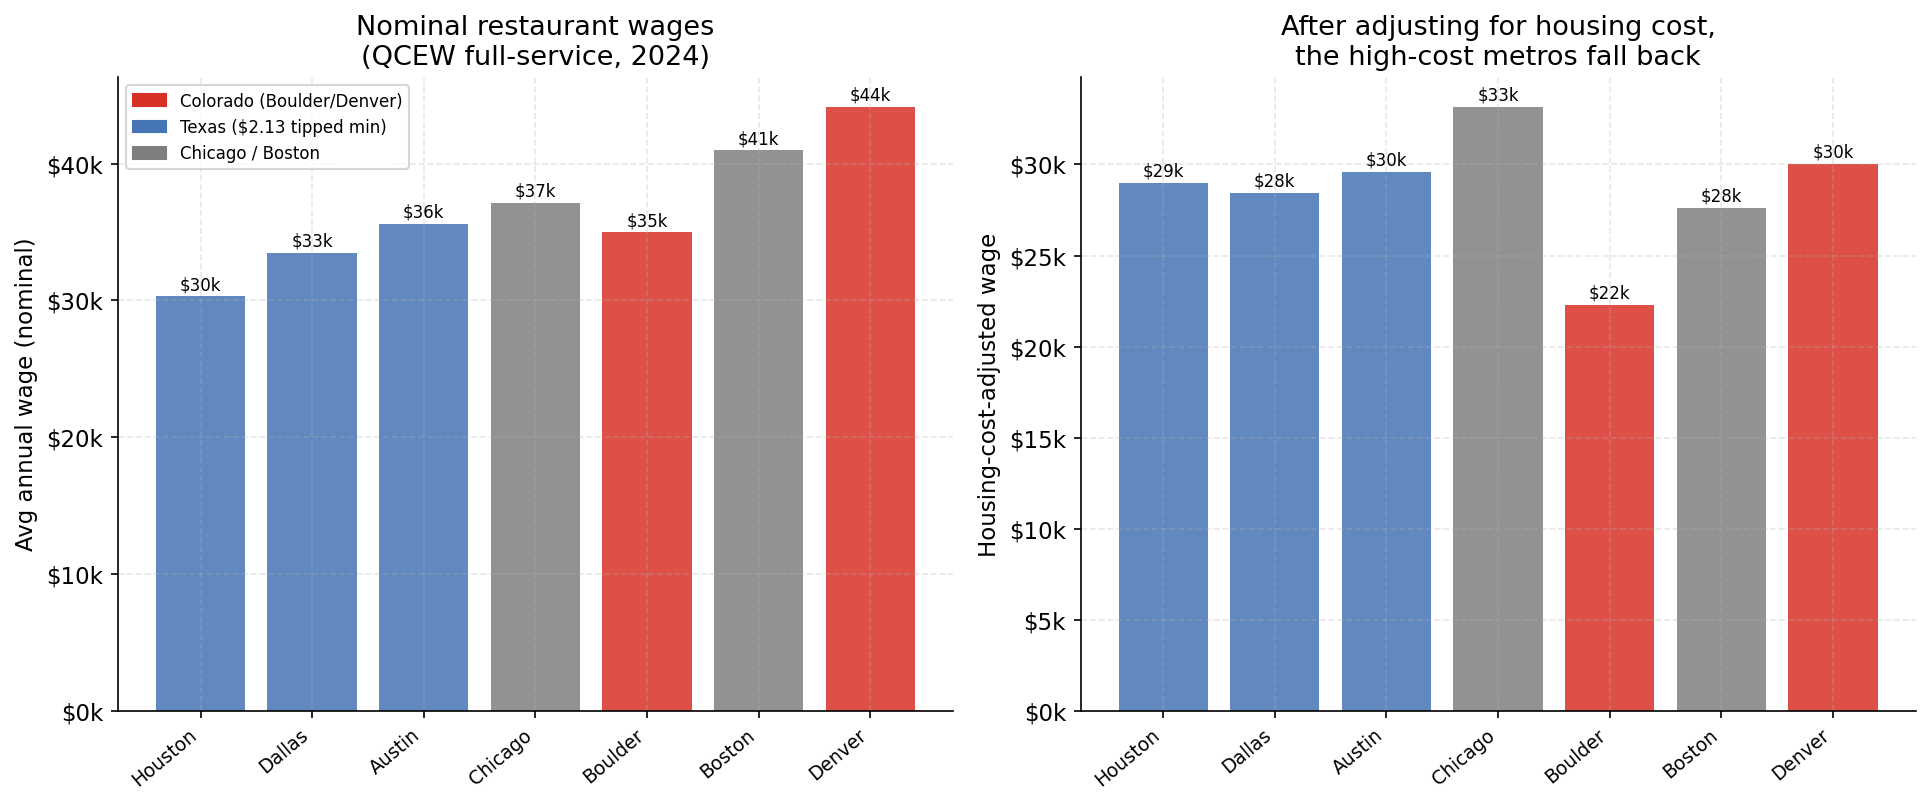

Saved: resp_fig4_metro_realwage.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

order = ["Houston","Dallas","Austin","Chicago","Boulder","Boston","Denver"]
c = combined.loc[order]
xpos = np.arange(len(order))
co_color = ["#d73027" if m in ("Boulder","Denver") else "#4575b4" if m in ("Austin","Dallas","Houston")
            else "#7f7f7f" for m in order]

# Left: nominal
ax1.bar(xpos, c["avg_annual"], color=co_color, alpha=0.85)
ax1.set_xticks(xpos); ax1.set_xticklabels(order, rotation=40, ha="right", fontsize=9)
ax1.set_ylabel("Avg annual wage (nominal)")
ax1.set_title("Nominal restaurant wages\n(QCEW full-service, 2024)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}k"))
for x, v in zip(xpos, c["avg_annual"]):
    ax1.text(x, v+500, f"${v/1000:.0f}k", ha="center", fontsize=8)

# Right: housing-adjusted
ax2.bar(xpos, c["real_wage_housing"], color=co_color, alpha=0.85)
ax2.set_xticks(xpos); ax2.set_xticklabels(order, rotation=40, ha="right", fontsize=9)
ax2.set_ylabel("Housing-cost-adjusted wage")
ax2.set_title("After adjusting for housing cost,\nthe high-cost metros fall back")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}k"))
for x, v in zip(xpos, c["real_wage_housing"]):
    ax2.text(x, v+400, f"${v/1000:.0f}k", ha="center", fontsize=8)

import matplotlib.patches as mpatches
leg = [mpatches.Patch(color="#d73027", label="Colorado (Boulder/Denver)"),
       mpatches.Patch(color="#4575b4", label="Texas ($2.13 tipped min)"),
       mpatches.Patch(color="#7f7f7f", label="Chicago / Boston")]
ax1.legend(handles=leg, fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("resp_fig4_metro_realwage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resp_fig4_metro_realwage.png")

## 8. What the Wage Actually Buys: Rent Burden by Metro

The most direct measure: how much of a full-service restaurant wage does median
rent consume in each metro? Rent from the Zillow Observed Rent Index (ZORI),
wage from QCEW. A higher ratio means a worse squeeze.


In [12]:
# Zillow ZORI metro rents (latest 2025)
z = pd.read_csv(io.BytesIO(fetch(
    "https://files.zillowstatic.com/research/public_csvs/zori/Metro_zori_uc_sfrcondomfr_sm_month.csv")))
latest = [c for c in z.columns if c.startswith("2025")][-1]

def zori(metro):
    r = z[z["RegionName"].str.startswith(metro)]
    return float(r.iloc[0][latest]) if len(r) else None

ZORI_NAMES = {"Boulder":"Boulder","Denver":"Denver","Austin":"Austin","Dallas":"Dallas",
              "Houston":"Houston","Chicago":"Chicago","Boston":"Boston"}
rent = {m: zori(n) for m, n in ZORI_NAMES.items()}

afford = combined.copy()
afford["monthly_rent"] = pd.Series(rent)
afford["monthly_wage"] = afford["avg_annual"] / 12
afford["rent_share"]   = afford["monthly_rent"] / afford["monthly_wage"]

print("Rent burden: median rent as share of average restaurant monthly wage (2025):\n")
print(afford[["avg_annual","monthly_rent","rent_share"]]
      .sort_values("rent_share", ascending=False)
      .assign(avg_annual=lambda d: d["avg_annual"].map("${:,.0f}".format),
              monthly_rent=lambda d: d["monthly_rent"].map("${:,.0f}".format),
              rent_share=lambda d: d["rent_share"].map("{:.0%}".format))
      .to_string())
print("\n(30% is the standard affordability threshold. Every one of these metros")
print(" exceeds it for a single full-service worker — and Boulder sits near the top.)")

Rent burden: median rent as share of average restaurant monthly wage (2025):

        avg_annual monthly_rent rent_share
metro                                     
Boston     $40,974       $3,100        91%
Boulder    $34,977       $2,189        75%
Chicago    $37,127       $2,172        70%
Houston    $30,293       $1,631        65%
Dallas     $33,497       $1,656        59%
Austin     $35,622       $1,608        54%
Denver     $44,130       $1,874        51%

(30% is the standard affordability threshold. Every one of these metros
 exceeds it for a single full-service worker — and Boulder sits near the top.)


### Figure 5 — Rent as a share of restaurant wage, by metro

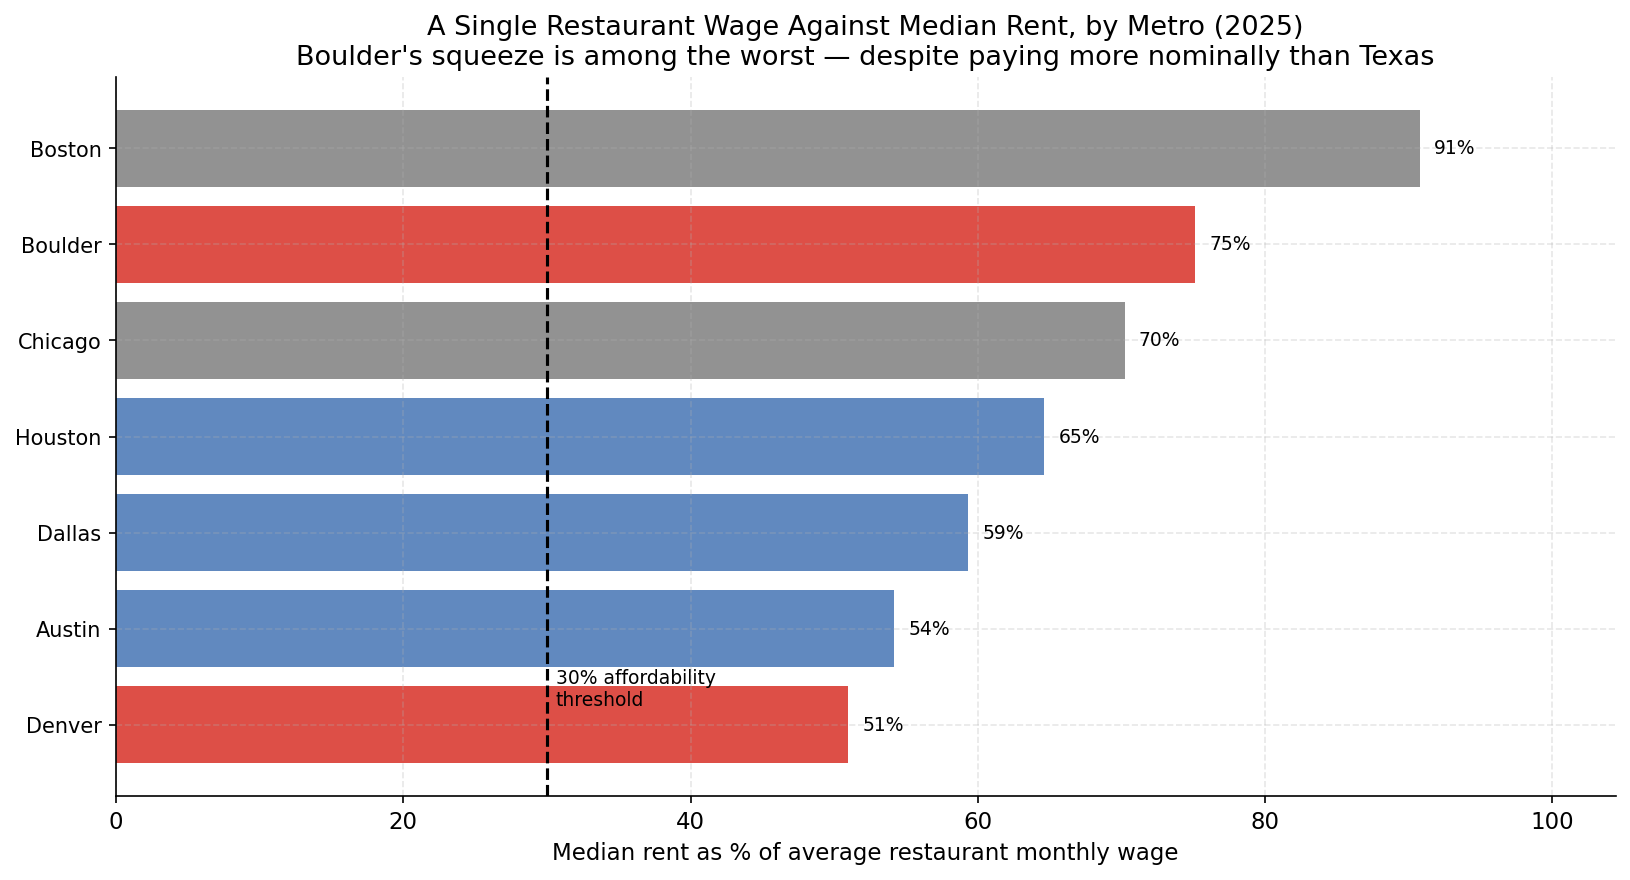

Saved: resp_fig5_rent_burden.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
a = afford.sort_values("rent_share")
ypos = np.arange(len(a))
bar_c = ["#d73027" if m in ("Boulder","Denver") else "#4575b4"
         if m in ("Austin","Dallas","Houston") else "#7f7f7f" for m in a.index]

ax.barh(ypos, a["rent_share"]*100, color=bar_c, alpha=0.85)
ax.axvline(30, color="black", lw=1.5, ls="--")
ax.text(30.6, 0.2, "30% affordability\nthreshold", fontsize=9)
ax.set_yticks(ypos); ax.set_yticklabels(a.index, fontsize=10)
ax.set_xlabel("Median rent as % of average restaurant monthly wage")
ax.set_title("A Single Restaurant Wage Against Median Rent, by Metro (2025)\n"
             "Boulder's squeeze is among the worst — despite paying more nominally than Texas")
for y, v in zip(ypos, a["rent_share"]*100):
    ax.text(v+1, y, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlim(0, max(a["rent_share"]*100)*1.15)

plt.tight_layout()
plt.savefig("resp_fig5_rent_burden.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resp_fig5_rent_burden.png")

## 9. Massachusetts, Chicago, D.C.: What Those Votes Actually Were

The rebuttal cites three "reversals" as evidence that tipped-wage policy fails.
Every one of them was about **fully eliminating the tip credit** — moving tipped
workers to 100% of the regular minimum wage with no offset at all (the "One Fair
Wage" model). That is the opposite of what Boulder is debating.

Boulder is **not** eliminating its tip credit. It is debating whether to *expand
the offset* — to let tipped base pay rise more slowly than the full minimum. The
cited cities were pulling back from the most worker-favorable possible policy.
Boulder is being asked to move toward the most employer-favorable one. Citing the
former to justify the latter is a category error.


In [14]:
# Verified policy facts (sourced inline in the column; vote counts from public reporting)
policy_facts = pd.DataFrame([
    {"Jurisdiction":"Massachusetts (Question 5, Nov 2024)",
     "What was on the table":"Eliminate tip credit entirely by 2029 (0% offset)",
     "Outcome":"Voters rejected 64-36; tip credit RETAINED",
     "Direction vs. Boulder":"Opposite — rejected ELIMINATION"},
    {"Jurisdiction":"Washington D.C. (Initiative 82, 2022-25)",
     "What was on the table":"Eliminate tip credit entirely by 2027",
     "Outcome":"Phaseout slowed/paused amid implementation fights",
     "Direction vs. Boulder":"Opposite — paused ELIMINATION"},
    {"Jurisdiction":"Chicago (One Fair Wage, 2023-26)",
     "What was on the table":"Eliminate tip credit entirely by 2028 (100% of min)",
     "Outcome":"March 2026 freeze (30-18) VETOED; override failed (30-19). "
               "May 2026: 2-yr pause (49-1), phaseout still reaches 100%",
     "Direction vs. Boulder":"Opposite — paused ELIMINATION, not reversed"},
    {"Jurisdiction":"Boulder (tip offset, 2026)",
     "What was on the table":"EXPAND the offset; slow tipped base-wage growth",
     "Outcome":"Under debate",
     "Direction vs. Boulder":"—"},
])

pd.set_option("display.max_colwidth", 60)
print(policy_facts.to_string(index=False))
print()
print("KEY DISTINCTION:")
print("  Chicago tipped workers, even after the 'freeze,' sit at 76% of a $16.60")
print("  minimum = $12.62/hr base, still on track to 100%. The fight there is over")
print("  how fast to REACH full minimum wage. Boulder's proposal moves the other")
print("  way: a larger offset means a LOWER base wage relative to the minimum.")

                            Jurisdiction                               What was on the table                                                                                                             Outcome                       Direction vs. Boulder
    Massachusetts (Question 5, Nov 2024)   Eliminate tip credit entirely by 2029 (0% offset)                                                                          Voters rejected 64-36; tip credit RETAINED             Opposite — rejected ELIMINATION
Washington D.C. (Initiative 82, 2022-25)               Eliminate tip credit entirely by 2027                                                                   Phaseout slowed/paused amid implementation fights               Opposite — paused ELIMINATION
        Chicago (One Fair Wage, 2023-26) Eliminate tip credit entirely by 2028 (100% of min) March 2026 freeze (30-18) VETOED; override failed (30-19). May 2026: 2-yr pause (49-1), phaseout still reaches 100% Opposite — paused ELIMINATION, n

## 10. Metro Comparison — Numbers for the Column

In [15]:
print("=" * 66)
print("CROSS-CITY COMPARISON — KEY NUMBERS")
print("=" * 66)
print("\n[A] NOMINAL WAGES (QCEW full-service, 2024) — refutes 'same everywhere':")
for m in ["Denver","Boston","Chicago","Austin","Boulder","Dallas","Houston"]:
    print(f"    {m:<10} ${combined.loc[m,'avg_annual']:>8,.0f}/yr")
print("\n[B] HOUSING COST (BEA RPP housing, US=100, 2024):")
for m in ["Boulder","Denver","Boston","Dallas","Austin","Chicago","Houston"]:
    print(f"    {m:<10} {combined.loc[m,'rpp_housing']:>6.0f}")
print("\n[C] RENT BURDEN (median rent / avg restaurant monthly wage, 2025):")
for m in afford.sort_values('rent_share', ascending=False).index:
    print(f"    {m:<10} {afford.loc[m,'rent_share']:>5.0%}")
print("\n[D] POLICY DIRECTION:")
print("    MA / DC / Chicago debated ELIMINATING the tip credit (One Fair Wage).")
print("    Boulder is debating EXPANDING the offset. Opposite directions.")
print("=" * 66)

CROSS-CITY COMPARISON — KEY NUMBERS

[A] NOMINAL WAGES (QCEW full-service, 2024) — refutes 'same everywhere':
    Denver     $  44,130/yr
    Boston     $  40,974/yr
    Chicago    $  37,127/yr
    Austin     $  35,622/yr
    Boulder    $  34,977/yr
    Dallas     $  33,497/yr
    Houston    $  30,293/yr

[B] HOUSING COST (BEA RPP housing, US=100, 2024):
    Boulder       157
    Denver        147
    Boston        148
    Dallas        118
    Austin        120
    Chicago       112
    Houston       105

[C] RENT BURDEN (median rent / avg restaurant monthly wage, 2025):
    Boston       91%
    Boulder      75%
    Chicago      70%
    Houston      65%
    Dallas       59%
    Austin       54%
    Denver       51%

[D] POLICY DIRECTION:
    MA / DC / Chicago debated ELIMINATING the tip credit (One Fair Wage).
    Boulder is debating EXPANDING the offset. Opposite directions.


## 11. Methodology & Limitations

**ACS B24022** is explicitly *Full-Time, Year-Round Workers and Median Earnings
by Sex and Detailed Occupation*. The full-time, year-round restriction is the
basis for the hours-consistency argument in Section 1.

**QCEW** counts employment via the unemployment-insurance system and is the most
complete establishment-level employment source. 2025 annual averages are used as
published; if a quarter is still preliminary, figures may revise slightly. NAICS
722511 is full-service restaurants specifically; 7225 includes limited-service.

**OEWS wages include tips** (built from total employer-reported earnings) but
OEWS is known to under-capture cash tips, which would bias the occupation medians
*downward* — i.e., conservative against the worker-wage side of the argument, and
even more damning for a $40/hr claim. OEWS does not report actual hours worked.

**Geography:** OEWS Boulder MSA (CBSA 14500) post-2004; "Boulder-Longmont PMSA"
pre-2004. QCEW Boulder County (FIPS 08013). These are not identical footprints.

**The Denver "natural experiment"** cited by the rebuttal (Denver vs. Austin/
Dallas/Houston) can be reproduced with OEWS metro files for those CBSAs via the
same pipeline; it is omitted here pending the local OEWS zips for Texas metros.

**Reproducibility:** Section 2 runs live against the BLS QCEW Open Data API with
no key. Sections 1 and 4 are self-contained. Section 3 reads the local OEWS panel
from `oews_boulder.py`; set `STUB_MODE` aside by providing that file.
